In [1]:
using Revise
using PVlib

using HTTP
using JSON
using DataFrames
using Dates
using CSV
using Plots
using Statistics
using LinearAlgebra
using TimeZones
using Random

using Optim
using Zygote
using FiniteDiff
using ForwardDiff


In [ ]:
latitude = 35.95
longitude = -75.125

api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"

start_monthday=(1, 1)
end_monthday=(1, 1)

weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)

println(weather_data[12])

WeatherSample
────────────
time               │ 2019-01-01T11:00:00-05:00
ghi                │ 236.0
dni                │ 98.0
dhi                │ 186.0
temp_air           │ 16.2
temp_dew           │ 15.8
relative_humidity  │ missing
pressure           │ 1016.0
wind_speed         │ 5.9
wind_direction     │ 250.0
albedo             │ 0.01



In [ ]:
latitude = 35.95
longitude = -75.125
altitude = 0.0

api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"

start_monthday=(1, 1)
end_monthday=(1, 1)

number_of_panels = 1
surface_azimuth = 180.0
surface_tilt = latitude

# try zygote one function at a time
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)

# area of 0.343 m^2, 9 cells per column with 4 columns, 0.526 x 0.652 m
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed

pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

In [ ]:
# prescribe WEC motion in 6 degrees of freedom for 100 seconds
time = range(0, 500, 1001)
amplitude = [1.0, 0.1, 1.0, 0.2, 1.0, 0.2]
#amplitude = [0, 0, 0, 1.4, 0, 0]
period = 10 # seconds

ω = 2π / period
WEC_response = amplitude' .* sin.(ω .* time);


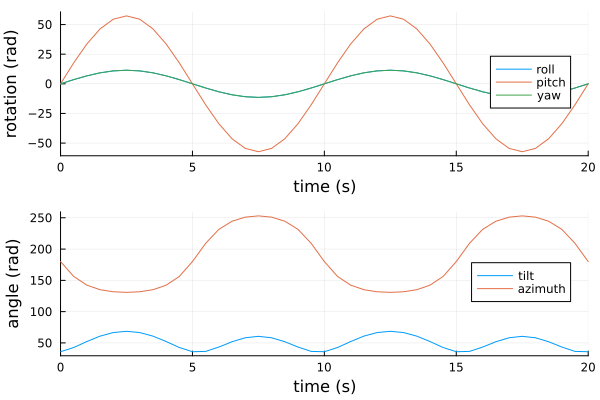

In [ ]:
# translational degrees of freedom don't impact the orientation and tilt direction
installation_tilt = surface_tilt
installation_azimuth = 180.0
initial_yaw = 0.0
panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, installation_tilt, installation_azimuth, initial_yaw)


t = time                      # length N
x = WEC_response[:,1]; y = WEC_response[:,2]; z = WEC_response[:,3]
roll  = WEC_response[:,4]
pitch = WEC_response[:,5]
yaw   = WEC_response[:,6]

# 2) Rotational motions
p2 = plot(t, roll*180/pi,  label="roll",  xlabel="time (s)", ylabel="rotation (rad)",xlims=(0, 20),)
plot!(p2, t, pitch*180/pi, label="pitch")
plot!(p2, t, yaw*180/pi,   label="yaw")

# 3) Panel angles
p3 = plot(t, panel_tilt, label="tilt", xlabel="time (s)", ylabel="angle (rad)", xlims=(0, 20),)
plot!(p3, t, panel_azimuth,   label="azimuth")

plot(p2, p3, layout=(2,1), legend=:right)

In [ ]:
# model for the albedo in ocean conditions
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
sol_position = get_solar_position(latitude, longitude, altitude, weather_data[12])

# albedo from NSRDB generall not accurate over water, so use a model based on solar position and weather conditions for ocean surfaces
albedo = get_ocean_surface_albedo(weather_data[12], sol_position) 
println("Albedo: ", albedo)

#plot(getfield.(weather_data, :time), albedo, label="Albedo vs time", xlabel="time", ylabel="Albedo", legend=:topright)

Albedo: 0.06193415557060577


In [ ]:
total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data[12], sol_position, albedo, time)

cell_temp_orig = sapm_cell_temperature(total_irradiance, weather_data[12]) 
cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data[12]);

#plot(cell_temp_orig, :cell_temperature, label="Orig Cell Temperature")
#plot!(cell_temp, :cell_temperature, label="Rolling Average Cell Temperature")

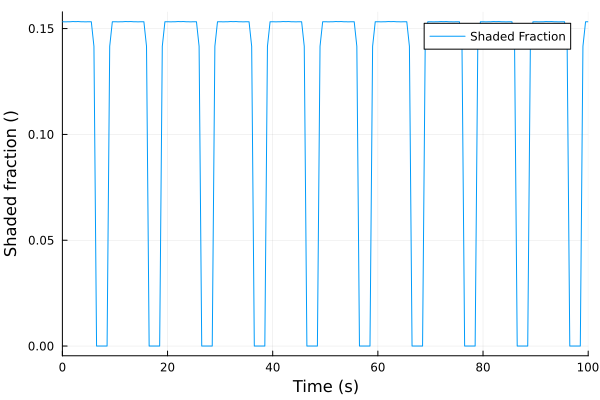

In [ ]:
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])

# A box/beam above the panel with respect to the panel's local coordinates
obstacle = BoxObstacle(
    -1.0, 1.0,   # x-range
    -0.05, 0.05,     # y-range
    0.5, 0.6   # z-range
)

f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle);

plot(time, f_shade, xlabel="Time (s)", ylabel="Shaded fraction ()", label="Shaded Fraction", legend=:topright, xlims=(0, 100))

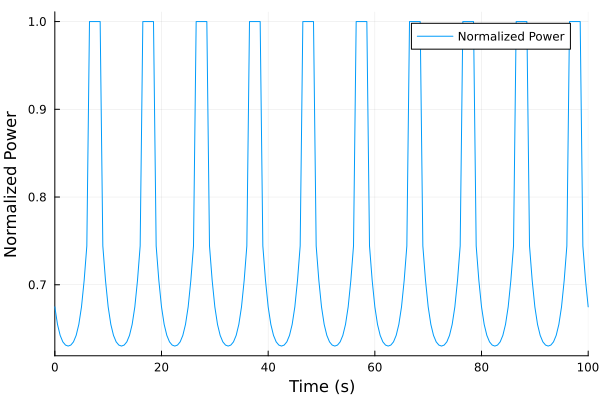

In [ ]:
power_norm = get_power_norm(total_irradiance, f_shade, 9);

# Note that power normalization is approximately 1 when shaded fraction is below critical shading (1/n_cells_per_column).
plot(time, power_norm, xlabel="Time (s)", ylabel="Normalized Power", label="Normalized Power", legend=:topright, xlims=(0, 100))

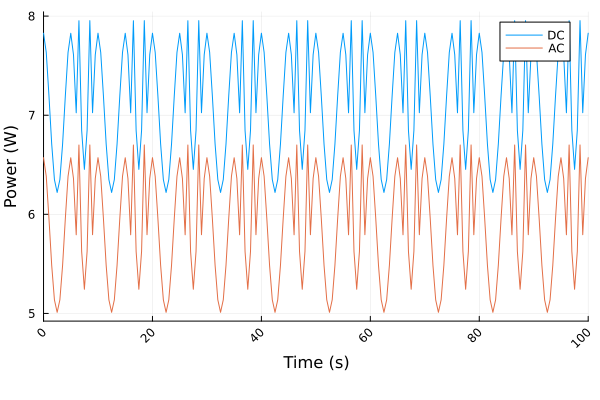

In [ ]:
# assume the simulation is done for the 12th hour on this date
# in the future, we can allow time/date input to specify
sol_position = get_solar_position(latitude, longitude, altitude, weather_data[12])
total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data[12], sol_position, albedo, time)

cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data[12]) 
effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)

ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)

plot(dc_components_shaded, :p_mp, :elapsed, label="DC")
plot!(ac_power, :ac_power, :elapsed, label="AC", xlabel="Time (s)", ylabel="Power (W)", legend=:topright, xrotation = 45, bottom_margin=8Plots.mm, xlims=(0, 100))


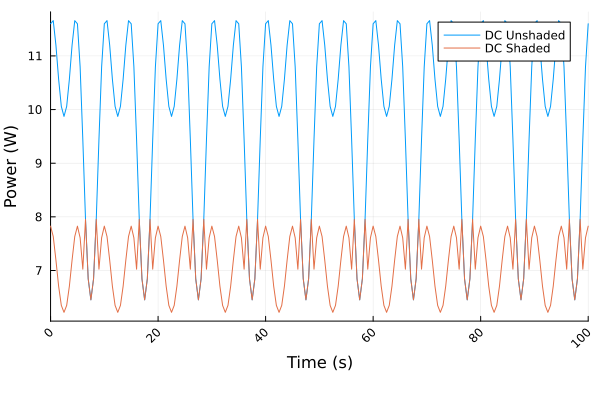

In [ ]:
dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp)

dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)

plot(dc_components, :p_mp, :elapsed, label="DC Unshaded")
plot!(dc_components_shaded, :p_mp, :elapsed, label="DC Shaded", xlabel="Time (s)", ylabel="Power (W)", xrotation = 45, bottom_margin=8Plots.mm, xlims=(0, 100))
#plot!(time, 10*power_norm, label="Power normalization factor", legend=:topright, xlims=(0, 100))

In [ ]:
# optimize the initial panel tilt to maximize average power using Zygote
# assume initial yaw is always the same

# create function that support initial tilt input
function dc_power_return(latitude, longitude, altitude, 
                        initial_tilt, initial_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)
    
    panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, initial_tilt, initial_azimuth)

    total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data, sol_position, albedo, sim_time) 
    cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data)

    effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

    f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle, nx=10, ny=10)
    power_norm = get_power_norm(total_irradiance, f_shade, n_cells_per_column)

    dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)
    ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)
    return getfield.(dc_components_shaded, :p_mp)
end

dc_power_return (generic function with 1 method)

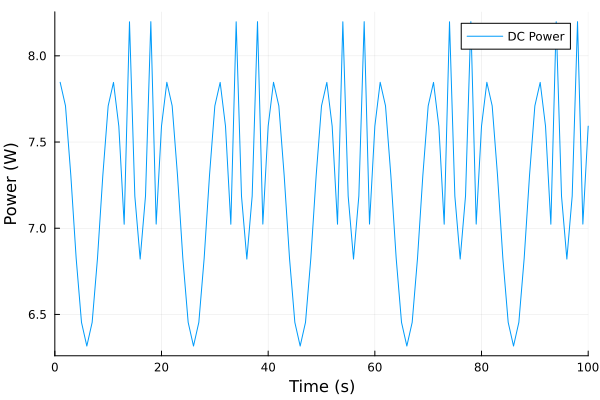

In [ ]:
# location and installation details for pioneer
latitude = 35.95
longitude = -75.125
altitude = 0.0 # m
api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"
start_monthday=(1, 1)
end_monthday=(1, 1)
number_of_panels = 1
initial_azimuth = 180.0
initial_tilt = latitude
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed
pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

# create example WEC resposne
time = range(0, 500, 1001)
amplitude = [1, 0.1, 1, 0.1, 1, 0.2]
period = 10 # seconds
ω = 2π / period
WEC_response = amplitude' .* sin.(ω .* time)

# installation characteristics
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])
# A box above the panel
obstacle = BoxObstacle(
    -0.5, 0.5,   # x-range
    -0.3, 0.3,     # y-range
    0.4, 0.5   # z-range
)
n_cells_per_column = 9

# import weather data, calculate solar position, and corresponding albedo
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
weather_data = weather_data[12] # just use the 12th hour for this simulation
sol_position = get_solar_position(latitude, longitude, altitude, weather_data)
albedo = get_ocean_surface_albedo(weather_data, sol_position)

dc_power = dc_power_return(latitude, longitude, altitude, initial_tilt, initial_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

plot(dc_power, label="DC Power", xlabel="Time (s)", ylabel="Power (W)", legend=:topright, xlims=(0, 100))

In [ ]:
function objective(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)

    avg_power = mean(dc_power_return(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time))
    return -avg_power
end

installation_tilt = latitude
installation_azimuth = 180.0

check_mean_power = objective(latitude, longitude, altitude, installation_tilt, installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)
println("Mean power for installation tilt: ", -check_mean_power)

mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

Mean power for installation tilt: 7.271906372401438


#2 (generic function with 1 method)

In [ ]:
fd_using_fd = FiniteDiff.finite_difference_derivative(mean_power, initial_tilt, Val(:central))

0.0015049799842390345

In [ ]:
ad_using_fd = ForwardDiff.derivative(mean_power, initial_tilt)

0.0015049799837490766

In [ ]:
# Optimize installation tilt

function g!(G, orientation)
    ForwardDiff.gradient!(G, mean_power, orientation)
end

tilt0 = [surface_tilt]
tilt0_lower = [0.0]
tilt0_upper = [90.0]
res = optimize(mean_power, g!, tilt0_lower, tilt0_upper, tilt0, Fminbox(BFGS()))

println("Optimal initial tilt: ", res.minimizer[1])
println("Maximum mean power: ", -res.minimum)

Optimal initial tilt: 34.71000557636398
Maximum mean power: 7.272837955581454


In [ ]:
# Optimize installation tilt and azimuth with Latin-hypercube multistart.
mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], orientation[2], weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

function g!(G, orientation)
    ForwardDiff.gradient!(G, mean_power, orientation)
end

lower = [0.0, 0.0]
upper = [90.0, 360.0]

function latin_hypercube(lower, upper; n_samples=10 * length(lower), rng=Random.default_rng(), centered=false)
    length(lower) == length(upper) || throw(DimensionMismatch("lower and upper must have the same length"))
    n_samples > 0 || throw(ArgumentError("n_samples must be positive"))

    n_dim = length(lower)
    samples = Matrix{Float64}(undef, n_samples, n_dim)
    for j in 1:n_dim
        lo = Float64(lower[j])
        hi = Float64(upper[j])
        isfinite(lo) && isfinite(hi) || throw(ArgumentError("Latin hypercube bounds must be finite"))
        hi >= lo || throw(ArgumentError("upper[$j] must be greater than or equal to lower[$j]"))

        width = hi - lo
        perm = randperm(rng, n_samples)
        offsets = centered ? fill(0.5, n_samples) : rand(rng, n_samples)
        for i in 1:n_samples
            unit = (perm[i] - 1 + offsets[i]) / n_samples
            samples[i, j] = lo + width * unit
        end
    end
    return samples
end

function optimizer_trace(result)
    points = [copy(state.metadata["x"]) for state in Optim.trace(result) if haskey(state.metadata, "x")]
    minimizer = copy(Optim.minimizer(result))
    if isempty(points) || !isapprox(points[end], minimizer; atol=1e-8, rtol=1e-8)
        push!(points, minimizer)
    end
    return reduce(vcat, (permutedims(point) for point in points))
end

function optimize_orientation_from_start(start)
    x0 = clamp.(Float64.(start), lower, upper)
    result = nothing
    elapsed_seconds = @elapsed begin
        result = optimize(
            mean_power,
            g!,
            lower,
            upper,
            x0,
            Fminbox(BFGS()),
            Optim.Options(store_trace=true, extended_trace=true),
        )
    end

    return (
        start = x0,
        result = result,
        minimizer = Optim.minimizer(result),
        minimum = Optim.minimum(result),
        maximum_power = -Optim.minimum(result),
        elapsed_seconds = elapsed_seconds,
        trace = optimizer_trace(result),
    )
end

rng = MersenneTwister(20260603)
seed_starts = [surface_tilt 180.0; 10.0 60.0]
lhs_starts = latin_hypercube(lower, upper; n_samples=10, rng=rng)
orientation_starts = vcat(seed_starts, lhs_starts)

println("Latin-hypercube multistart starts:")
for i in axes(orientation_starts, 1)
    println("start ", i, ": (", round(orientation_starts[i, 1]; digits=3), ", ", round(orientation_starts[i, 2]; digits=3), ")")
end

multistart_runs = [
    optimize_orientation_from_start(vec(orientation_starts[i, :]))
    for i in axes(orientation_starts, 1)
]

best_run_index = argmin([run.minimum for run in multistart_runs])
best_run = multistart_runs[best_run_index]
res = best_run.result

println("Latin-hypercube multistart optima:")
for (i, run) in enumerate(multistart_runs)
    println(
        "run ", i,
        ": start=", round.(run.start; digits=3),
        " -> optimum=", round.(run.minimizer; digits=3),
        ", mean power=", round(run.maximum_power; digits=6),
        ", solve time=", round(run.elapsed_seconds; digits=3), " s",
    )
end

println("Best run index: ", best_run_index)
println("Optimal installation tilt: ", best_run.minimizer[1])
println("Optimal installation azimuth: ", best_run.minimizer[2])
println("Maximum mean power: ", best_run.maximum_power)


Latin-hypercube multistart starts:
start 1: (35.95, 180.0)
start 2: (10.0, 60.0)
start 3: (33.903, 323.773)
start 4: (13.099, 349.675)
start 5: (3.638, 69.248)
start 6: (40.927, 104.929)
start 7: (57.145, 158.97)
start 8: (75.102, 4.924)
start 9: (82.011, 264.221)
start 10: (70.253, 238.537)
start 11: (21.793, 185.462)
start 12: (48.1, 118.899)
Latin-hypercube multistart optima:
run 1: start=[35.95, 180.0] -> optimum=[9.175, 84.748], mean power=7.866279, solve time=10.704 s
run 2: start=[10.0, 60.0] -> optimum=[3.774, 46.82], mean power=7.944396, solve time=3.856 s
run 3: start=[33.903, 323.773] -> optimum=[2.513, 351.183], mean power=7.94859, solve time=3.363 s
run 4: start=[13.099, 349.675] -> optimum=[2.513, 351.183], mean power=7.94859, solve time=3.883 s
run 5: start=[3.638, 69.248] -> optimum=[6.948, 83.398], mean power=7.866916, solve time=2.49 s
run 6: start=[40.927, 104.929] -> optimum=[13.349, 113.745], mean power=7.746837, solve time=2.355 s
run 7: start=[57.145, 158.97] -> 

Saved multistart summary plot: c:\Users\jtgrasb\Documents\GitHub\PVlib.jl\examples\figures\wec_motion_multistart_summary.png


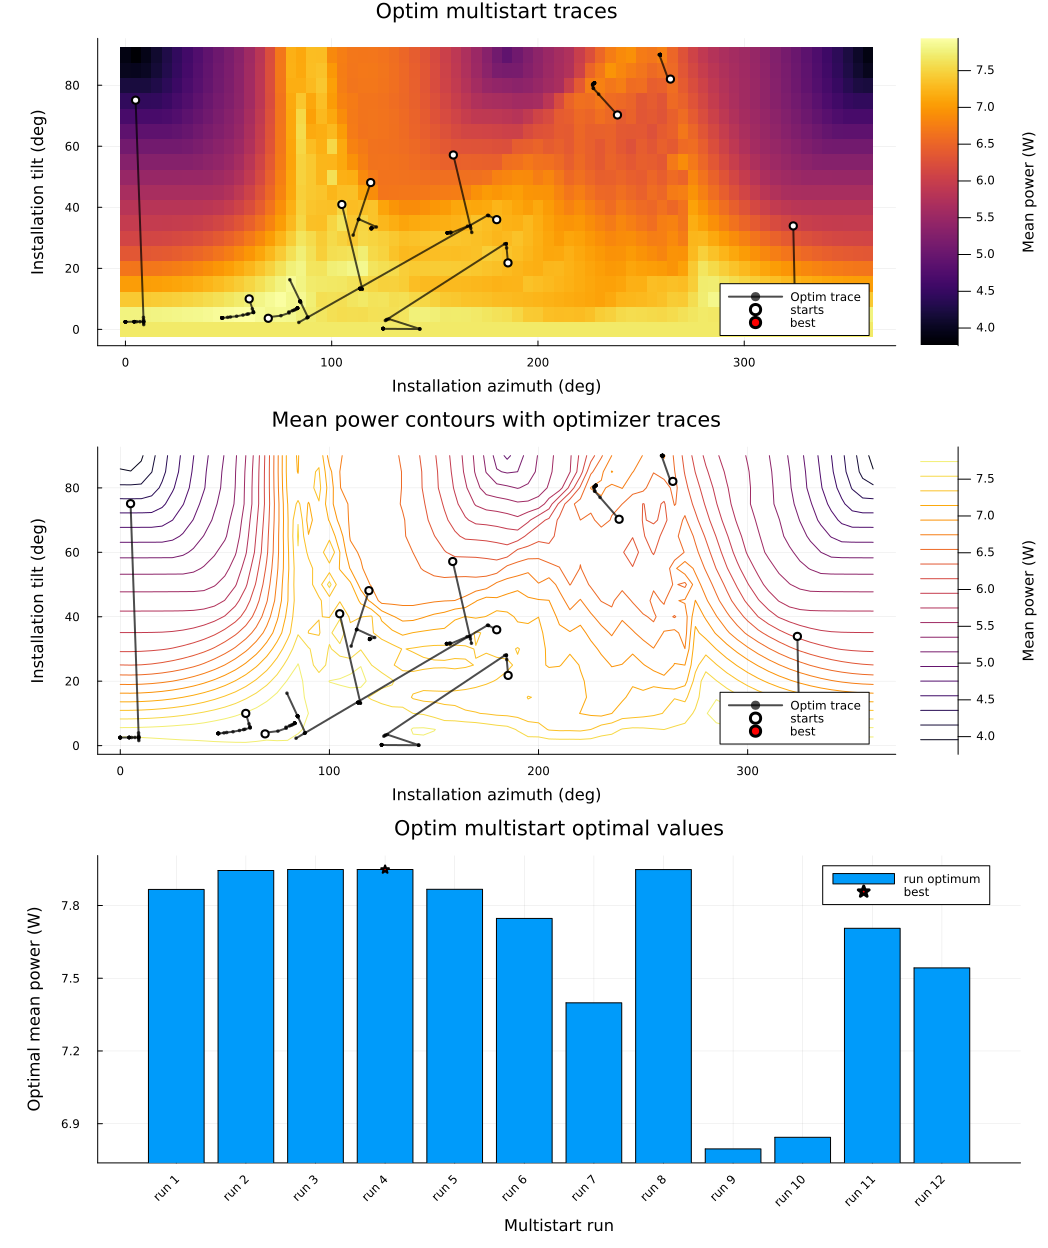

In [ ]:
tilt_range = 0.0:5.0:90.0
azimuth_range = 0.0:5.0:360.0

power_grid = [
    -objective(
        latitude, longitude, altitude,
        tilt, azimuth,
        weather_data, sol_position,
        pv_module, pv_inverter, WEC_response,
        panel, obstacle, n_cells_per_column,
        albedo, time
    )
    for tilt in tilt_range, azimuth in azimuth_range
]

function trace_with_periodic_breaks(trace; azimuth_jump_break=180.0)
    azimuth = Float64[]
    tilt = Float64[]
    for i in axes(trace, 1)
        if i > first(axes(trace, 1)) && abs(trace[i, 2] - trace[i - 1, 2]) > azimuth_jump_break
            push!(azimuth, NaN)
            push!(tilt, NaN)
        end
        push!(azimuth, trace[i, 2])
        push!(tilt, trace[i, 1])
    end
    return azimuth, tilt
end

p1 = heatmap(
    azimuth_range,
    tilt_range,
    power_grid,
    xlabel="Installation azimuth (deg)",
    ylabel="Installation tilt (deg)",
    colorbar_title="Mean power (W)",
    title="Optim multistart traces",
    legend=:bottomright,
)

for (i, run) in enumerate(multistart_runs)
    if size(run.trace, 1) > 1
        trace_azimuth, trace_tilt = trace_with_periodic_breaks(run.trace)
        plot!(p1, trace_azimuth, trace_tilt, linewidth=2, marker=:circle, markersize=2,
              color=:black, linealpha=0.7, markeralpha=0.7,
              label=i == 1 ? "Optim trace" : "")
    end
end
scatter!(p1, orientation_starts[:, 2], orientation_starts[:, 1], color=:white, markerstrokecolor=:black, label="starts")
scatter!(p1, [best_run.minimizer[2]], [best_run.minimizer[1]], color=:red, markerstrokecolor=:black, label="best")

p2 = contour(
    azimuth_range,
    tilt_range,
    power_grid,
    xlabel="Installation azimuth (deg)",
    ylabel="Installation tilt (deg)",
    title="Mean power contours with optimizer traces",
    levels=20,
    colorbar_title="Mean power (W)",
    legend=:bottomright,
)

for (i, run) in enumerate(multistart_runs)
    if size(run.trace, 1) > 1
        trace_azimuth, trace_tilt = trace_with_periodic_breaks(run.trace)
        plot!(p2, trace_azimuth, trace_tilt, linewidth=2, marker=:circle, markersize=2,
              color=:black, linealpha=0.7, markeralpha=0.7,
              label=i == 1 ? "Optim trace" : "")
    end
end
scatter!(p2, orientation_starts[:, 2], orientation_starts[:, 1], color=:white, markerstrokecolor=:black, label="starts")
scatter!(p2, [best_run.minimizer[2]], [best_run.minimizer[1]], color=:red, markerstrokecolor=:black, label="best")

run_indices = collect(1:length(multistart_runs))
run_powers = [run.maximum_power for run in multistart_runs]
power_span = maximum(run_powers) - minimum(run_powers)
power_margin = max(0.02, 0.05 * power_span)
p3 = bar(
    run_indices,
    run_powers,
    xlabel="Multistart run",
    ylabel="Optimal mean power (W)",
    title="Optim multistart optimal values",
    legend=:topright,
    xticks=(run_indices, string.("run ", run_indices)),
    xrotation=45,
    ylims=(minimum(run_powers) - power_margin, maximum(run_powers) + power_margin),
    label="run optimum",
)
scatter!(p3, [best_run_index], [best_run.maximum_power], color=:red, marker=:star5, markerstrokecolor=:black, label="best")

summary_plot = plot(p1, p2, p3, layout=(3, 1), size=(1050, 1250), left_margin=10Plots.mm)
figures_dir = isdir(joinpath(pwd(), "examples", "figures")) ? joinpath(pwd(), "examples", "figures") : joinpath(pwd(), "figures")
mkpath(figures_dir)
summary_plot_path = joinpath(figures_dir, "wec_motion_multistart_summary.png")
savefig(summary_plot, summary_plot_path)
println("Saved multistart summary plot: ", summary_plot_path)
summary_plot


In [ ]:
# Reverse-mode Zygote is not used for the multistart workflow above.
# On Julia 1.12 this full moving-shadow objective can segfault during Zygote compilation;
# keep gradient checks to the ForwardDiff/FiniteDiff cells above until a reverse-mode rule is added.
nothing
